## GRACE processing script 

### This script processes GRACE data for the UCRB from three sources (JPL, CSR, GSFC). The data are area-weighted based on their relationship with the Alaska shapefile. Uncertainty is calculated by taking the standard deviation of the three products. 

### The final dataframe has been exported as GRACE_UCRB_AreaWeighted_DF.csv to the ExperimentRuns/pumping/Total directory and has replaced the former GRACE data in PF processing scripts. 

### At the end of this script, there is a comparison between this newly-processed GRACE data, the GRACE data processed by the cell-center method in ProcessingGRACE_2024, and the GRACE data that I processed in 2022. 

### Import usefule Libraries

In [10]:
#!pip show exactextract
#!pip install exactextract
#!pip install netCDF4
#!pip install xagg
#!export PYTHONPATH=$PYTHONPATH:/home/SHARED/virtual-environments/parflow-shared/conda/lib/python3.11/site-packages

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import rasterio as rst
from pyproj import Proj, transform, CRS
import geopandas as gpd
import netCDF4 as nc

import exactextract
from exactextract import exact_extract
import xagg as xa
!pwd

/Users/ms6985/Desktop/Research_new/Grazing_GRACE-main/GlaMBIE


### Important Info/Links

https://isciences.github.io/exactextract/operations.html 

https://storymaps.arcgis.com/stories/5309a3a8eabd41478e5a47263a07e2f1

CSR Data: https://www2.csr.utexas.edu/grace/RL06.html

JPL Data: https://grace.jpl.nasa.gov/data/get-data/jpl_global_mascons/

GSFC Data: https://earth.gsfc.nasa.gov/geo/data/grace-mascons (GSFC.glb.200204_202406_RL06v2.0_OBP-ICE6GD_HALFDEGREE.nc) 

" HHU-IPM GRACE records for monthly TWSA values are in mm of equivalent water height for the reference period April 2002 to May 2022 in the form of a NetCDF file. They are anomalies regarding the period from January 2004 to December 2009. The data sets are provided at a spatial partitioning of 0.25-by-0.25 arc-degrees on the ellipsoid associated with the World Geodetic System 1984 (WGS84). The resolution is still GRACE’s native resolution which is 300–400 km, mainly due to the GRACE’s orbital configurations."

https://www.nature.com/articles/s41597-023-02122-1

### Read the India Shapefile:


<Figure size 1000x1000 with 0 Axes>

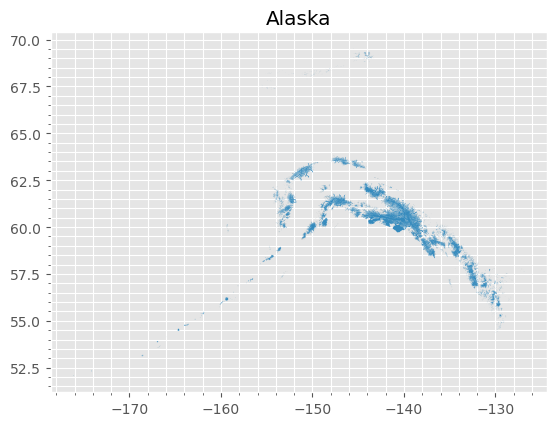

<Figure size 640x480 with 0 Axes>

In [14]:
basin_shapefile = gpd.read_file("/Users/ms6985/Desktop/Research_new/Grazing_GRACE-main/GlaMBIE/RGI2000-v7.0-C-01_alaska/RGI2000-v7.0-C-01_alaska.shp")

# Plot of entire Colorado River Basin
plt.style.use('ggplot')
plt.figure(figsize=[10,10])
basin_shapefile.plot()
plt.title("Alaska")
plt.grid(which="minor")
plt.minorticks_on()
plt.show()

#basin_shapefile.columns
basin_shapefile.head()

#print(basin_shapefile(column='name'))
#print(basin_shapefile[column='Haryana'].drop_duplicates())

plt.savefig(f"map_Alaska.png", dpi=300, bbox_inches='tight')

### Read the GRACE Data  (JPL, CSR, GSFC) 

In [17]:
# JPL:
jpl = 'GRCTellus.JPL.200204_202511.GLO.RL06.3M.MSCNv04CRI.nc'
grace_jpl = xr.open_dataset(jpl)

# # CSR: 
# csr = 'water:geospatial/CSR_GRACE_GRACE-FO_RL06_Mascons_all-corrections_v02.nc'
# grace_csr = xr.open_dataset(csr)

# # GSFC
# gsfc = 'water:geospatial/gsfc.glb_.200204_202406_rl06v2.0_obp-ice6gd_halfdegree.nc'

# grace_gsfc = xr.open_dataset(gsfc)


#### using **xagg**

https://xagg.readthedocs.io/en/latest/notebooks/base_run.html

https://xagg.readthedocs.io/en/latest/xagg.html#xagg.core.aggregate

https://xagg.readthedocs.io/en/latest/xagg.html#xagg.wrappers.pixel_overlaps:~:text=%5Bsource%5D-,%EF%83%81,-Wrapper%20function%20for

In [19]:

# Calculate overlaps
ds_jpl = grace_jpl

gdf= basin_shapefile#one_state#

# Area Weighted Avg Weight File
weightmap_jpl = xa.pixel_overlaps(ds_jpl,gdf)

# Aggregated to Shapefile
aggregated_jpl = xa.aggregate(ds_jpl,weightmap_jpl)

# Example as an xarray dataset
ds_out_jpl = aggregated_jpl.to_dataset()


creating polygons for each pixel...
lat/lon bounds not found in dataset; they will be created.
calculating overlaps between pixels and output polygons...
success!
adjusting grid... (this may happen because only a subset of pixels were used for aggregation for efficiency - i.e. [subset_bbox=True] in xa.pixel_overlaps())
grid adjustment successful
aggregating lwe_thickness...
aggregating uncertainty...
aggregating lat_bounds...
aggregating lon_bounds...
aggregating land_mask...
aggregating scale_factor...
aggregating mascon_ID...
aggregating GAD...
all variables aggregated to polygons!


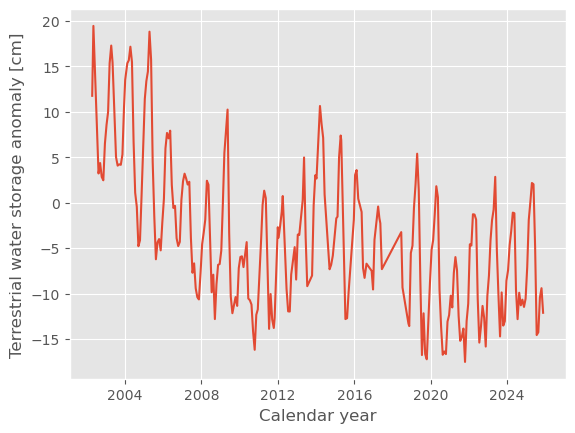

In [24]:
plt.figure()
plt.plot(ds_out_jpl.time,ds_out_jpl['lwe_thickness'][0,:])
plt.xlabel('Calendar year')
plt.ylabel('Terrestrial water storage anomaly [cm]')
# Save as PDF
plt.savefig(f"Alaska.pdf", dpi=300, bbox_inches='tight')
plt.savefig(f"Alaska.png", dpi=300, bbox_inches='tight')

In [91]:
"""
creating a dataframe of nans with dates; will merge other dataframes to this one, and if they have a missing date then the 
value of the merged dataframe will remain NaN
"""

start_date = '2002-01'
end_date = '2025-11'
start_date
# Create a datetime array with a monthly frequency
missing_datetime_array = pd.date_range(start=start_date, end=end_date, freq='YE').to_period('Y')  # 'Y' for yearly
#missing_datetime_array = pd.date_range(start=start_date, end=end_date, freq='ME').to_period('M')  # 'M' for monthly
missing_data_df = pd.DataFrame()
missing_data_df["anomaly_cm"] = np.zeros(23) * np.nan
missing_data_df.set_index(missing_datetime_array, inplace=True)


"""
creating dataframes for each of the products (jpl, csr, gsfc)
"""
jpl_df_lwe = ds_out_jpl['lwe_thickness'][0,:]
jpl_df_time = ds_out_jpl['time']
jpl_DF_raw = pd.DataFrame(data = {'JPL_cm':jpl_df_lwe}, index = jpl_df_time)
jpl_DF_raw.index = jpl_DF_raw.index.strftime('%Y')
jpl_DF_raw.index = pd.to_datetime(jpl_DF_raw.index).to_period('Y')

#csr_df_lwe = ds_out_csr['lwe_thickness'][0,:]
og_date = datetime.datetime(2002,1,1,0,0,0) # original date 
pd.to_datetime(og_date,format='%Y')


"""
merging each dataframe with the missing data dataframe (missing_data_df) 
"""
jpl_df_merged = jpl_DF_raw.merge(right = missing_data_df, how = 'right', left_index = True, right_index = True)
jpl_df_merged.drop('anomaly_cm', axis = 1, inplace=True)

"""
for duplicate dates, applying a nanmean operation to take the mean of the two date values. 
then, making sure that all values in the aggredated dataframes are float values. 

**each DF has 1-2 duplicate dates. 
"""
jpl_df_aggregated = jpl_df_merged.groupby(jpl_df_merged.index).apply(lambda x: np.nanmean(x, axis=0))
jpl_df_aggregated = jpl_df_aggregated.astype(float)

"""
now, merging all the dataframes into one final dataframe. Will calculate the avg and STD on this one and then save it. 
"""
GRACE_AreaWeighted_DF = pd.concat([jpl_df_aggregated], axis=1)
GRACE_AreaWeighted_DF.columns = ['JPL_cm']
GRACE_AreaWeighted_DF.index = GRACE_AreaWeighted_DF.index.to_timestamp(freq='M')


In [77]:
GRACE_AreaWeighted_DF

,JPL_cm
2002-01-31,7.220349
2003-01-31,9.077322
2004-01-31,6.879111
2005-01-31,4.556221
2006-01-31,1.445230
2007-01-31,-3.674043
2008-01-31,-5.212415
2009-01-31,-3.994105
2010-01-31,-9.671507
2011-01-31,-7.281804


In [89]:
"""
saving DF as CSV
"""

GRACE_AreaWeighted_DF.to_csv('Alaska_lwe.csv')


# Convert to Gigatons

In [249]:
# Calculate overlaps
ds_jpl = grace_jpl
#gdf = basin_shapefile  # one_state / one basin polygon (or dissolve first)
gdf = basin_shapefile#.dissolve()#.reset_index(drop=True)
gdf = gdf.to_crs("EPSG:4326")

# Make geometry valid
gdf["geometry"] = gdf["geometry"].make_valid()


# Area Weighted Avg Weight File (overlap fractions)
weightmap_jpl = xa.pixel_overlaps(ds_jpl, gdf)

# Aggregated to Shapefile (area-weighted mean LWE over polygon)
aggregated_jpl = xa.aggregate(ds_jpl, weightmap_jpl)

# Example as an xarray dataset
ds_out_jpl = aggregated_jpl.to_dataset()

Area_km2_final = np.sum(ds_out_jpl['area_km2'][:])


#as a single file
gdf = basin_shapefile.dissolve().reset_index(drop=True)
gdf = gdf.to_crs("EPSG:4326")

# Make geometry valid
gdf["geometry"] = gdf["geometry"].make_valid()


# Area Weighted Avg Weight File (overlap fractions)
weightmap_jpl = xa.pixel_overlaps(ds_jpl, gdf)

# Aggregated to Shapefile (area-weighted mean LWE over polygon)
aggregated_jpl = xa.aggregate(ds_jpl, weightmap_jpl)

# Example as an xarray dataset
ds_out_jpl = aggregated_jpl.to_dataset()

creating polygons for each pixel...
lat/lon bounds not found in dataset; they will be created.
calculating overlaps between pixels and output polygons...
success!
adjusting grid... (this may happen because only a subset of pixels were used for aggregation for efficiency - i.e. [subset_bbox=True] in xa.pixel_overlaps())
grid adjustment successful
aggregating lwe_thickness...
aggregating uncertainty...
aggregating lat_bounds...
aggregating lon_bounds...
aggregating land_mask...
aggregating scale_factor...
aggregating mascon_ID...
aggregating GAD...
all variables aggregated to polygons!
creating polygons for each pixel...
lat/lon bounds not found in dataset; they will be created.
calculating overlaps between pixels and output polygons...
success!
adjusting grid... (this may happen because only a subset of pixels were used for aggregation for efficiency - i.e. [subset_bbox=True] in xa.pixel_overlaps())
grid adjustment successful
aggregating lwe_thickness...
aggregating uncertainty...
aggre

In [250]:
# -----------------------------
# Convert to MASS (Gt)
# -----------------------------
rho_w = 1000.0  # kg/m^3

# 1) aggregated mean LWE over polygon (still in cm if your input is cm)
h_cm = ds_out_jpl['lwe_thickness'].isel(poly_idx=0)   # (time,)

# 2) polygon area in km^2 
A_km2 = ds_out_jpl['area_km2'].isel(poly_idx=0)   # (time,)

# 3) mass anomaly time series in Gt
mass_Gt = (h_cm * 0.01) * (Area_km2_final *1e6)* rho_w / 1e12   # cm -> m via 0.01, 1e12 is from kg to Gt

ds_out_jpl["mass_Gt"] = mass_Gt

mass_Gt

<xarray.DataArray (time: 251)> Size: 2kB
array([ 111.26998635,  110.41740435,   59.21202911,   47.4633878 ,
         48.82629115,   55.83345439,   64.83362636,   69.57241445,
         78.3725425 ,   82.5551627 ,   83.95692885,   79.66689987,
         53.29424949,   37.27911432,   27.81206677,   22.97625929,
         23.11978502,   35.94905749,   47.14552883,   59.67549703,
         65.157395  ,   73.70603256,   63.65996408,   52.54529432,
         29.11160962,    2.61933144,  -13.41918964,   -9.3707438 ,
          3.97935776,   22.54173212,   30.74799692,   36.98923134,
         44.93847061,   49.29334442,   43.6458999 ,   25.87960139,
          8.88507413,  -11.42951873,  -25.06077394,  -23.6546063 ,
        -12.56758022,    5.09433366,    4.83504729,   14.83822977,
         18.31763408,   25.00421316,   26.75731309,   16.47786684,
         -4.52602415,  -16.98172412,  -25.67918367,  -19.89920749,
        -17.5383372 ,  -13.96230371,    4.14892312,    9.91910596,
         16.45846396,   23.13652849,   17.70933625,    5.86732068,
         -9.03548215,  -28.24146253,  -40.32018056,  -41.50265466,
        -32.23209519,  -22.71745722,  -11.93532122,   -3.93340396,
          4.46865809,    6.83761537,    5.83618483,   -2.0275115 ,
        -13.36441177,  -28.52090063,  -40.44617216,  -38.96798466,
        -28.73933816,  -11.60302067,   -6.83804403,    1.70247756,
...
       -169.10327267, -176.04747639, -203.78711009, -229.33922593,
       -241.39108278, -237.99599309, -228.35380074, -217.82115192,
       -209.34876145, -195.82468626, -186.94766207, -186.12592117,
       -190.63115939, -202.61851561, -221.93489078, -236.47443955,
       -242.93807173, -241.58966671, -239.15773024, -222.69031225,
       -206.75424848, -200.95006935, -192.71172329, -189.51703145,
       -195.33685783, -203.98925996, -224.52519961, -243.44885974,
       -252.00690858, -251.34340374, -245.37338101, -236.26692899,
       -223.04486473, -208.19656614, -200.26667638, -196.03372623,
       -201.06914623, -213.45107072, -237.49209761, -254.35670698,
       -266.55158582, -265.70420961, -255.14578466, -245.23102755,
       -236.87669829, -230.75134729, -227.12468558, -221.88534659,
       -219.27324268, -230.99711178, -250.1067552 , -272.6670814 ,
       -283.78383668, -278.62756304, -275.83770457, -264.75110809,
       -252.55376384, -240.06617826, -234.2863461 , -231.73564727,
       -233.22256471, -238.5444788 , -259.81947876, -275.05598596,
       -284.1418167 , -283.1281539 , -276.78675571, -272.36119045,
       -255.74712159, -248.86065894, -245.68263574, -243.83332348,
       -240.83991713, -244.39459137, -257.16652058, -277.76672958,
       -294.56426858, -295.15512748, -288.13213628])
Coordinates:
    poly_idx  int64 8B 0
  * time      (time) datetime64[ns] 2kB 2002-04-17T12:00:00 ... 2025-11-16

In [251]:
#print('weight',weightmap_jpl)
#print('Aggregated',aggregated_jpl)
#print('Out',ds_out_jpl)
print('Area',ds_out_jpl['area_km2'].isel(poly_idx=0))
print('Area',ds_out_jpl['area_km2'][ds_out_jpl['poly_idx']==0])
print(ds_out_jpl['poly_idx'])
print(ds_out_jpl['area_km2'])

print("gdf CRS:", gdf.crs)
print("gdf bounds:", gdf.total_bounds)   # (minx, miny, maxx, maxy)

print("ds lon min/max:", float(ds_jpl.lon.min()), float(ds_jpl.lon.max()))
print("ds lat min/max:", float(ds_jpl.lat.min()), float(ds_jpl.lat.max()))

Area <xarray.DataArray 'area_km2' ()> Size: 8B
array(0.23919916)
Coordinates:
    poly_idx  int64 8B 0
Area <xarray.DataArray 'area_km2' (poly_idx: 1)> Size: 8B
array([0.23919916])
Coordinates:
  * poly_idx  (poly_idx) int64 8B 0
<xarray.DataArray 'poly_idx' (poly_idx: 1)> Size: 8B
array([0])
Coordinates:
  * poly_idx  (poly_idx) int64 8B 0
<xarray.DataArray 'area_km2' (poly_idx: 1)> Size: 8B
array([0.23919916])
Coordinates:
  * poly_idx  (poly_idx) int64 8B 0
gdf CRS: EPSG:4326
gdf bounds: [-176.142471   52.057273 -126.854495   69.513204]
ds lon min/max: -179.75 179.75
ds lat min/max: -89.75 89.75


In [252]:
mass_Gt.shape

(251,)

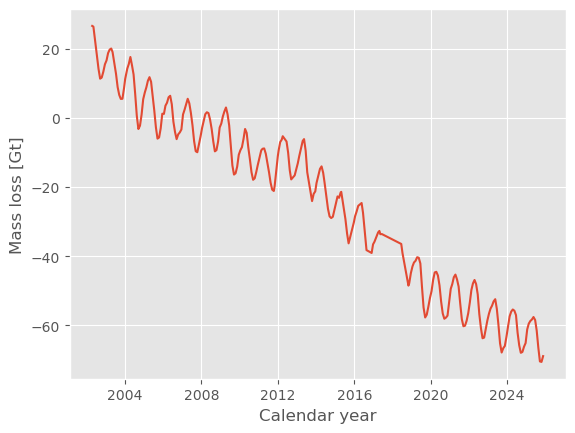

In [253]:
plt.figure()
plt.plot(ds_out_jpl.time,ds_out_jpl["mass_Gt"][:]*np.sum(ds_out_jpl['area_km2'][:]))
plt.xlabel('Calendar year')
plt.ylabel('Mass loss [Gt]')
# Save as PDF
plt.savefig(f"Alaska_mass.pdf", dpi=300, bbox_inches='tight')
plt.savefig(f"Alaska_mass.png", dpi=300, bbox_inches='tight')

In [171]:
"""
creating a dataframe of nans with dates; will merge other dataframes to this one, and if they have a missing date then the 
value of the merged dataframe will remain NaN
"""

start_date = '2002-01'
end_date = '2025-11'
start_date
# Create a datetime array with a monthly frequency
missing_datetime_array_ = pd.date_range(start=start_date, end=end_date, freq='YE').to_period('Y')  # 'Y' for yearly
#missing_datetime_array = pd.date_range(start=start_date, end=end_date, freq='ME').to_period('M')  # 'M' for monthly
missing_data_df = pd.DataFrame()
missing_data_df["anomaly_Gt"] = np.zeros(23) * np.nan
missing_data_df.set_index(missing_datetime_array, inplace=True)


"""
creating dataframes for each of the products (jpl, csr, gsfc)
"""
jpl_df_Gt = ds_out_jpl["mass_Gt"][:]
print(jpl_df_Gt.shape)

jpl_df_time = ds_out_jpl['time']
jpl_DF_raw = pd.DataFrame(data = {'JPL_Gt':jpl_df_Gt}, index = jpl_df_time)
jpl_DF_raw.index = jpl_DF_raw.index.strftime('%Y')
jpl_DF_raw.index = pd.to_datetime(jpl_DF_raw.index).to_period('Y')

#csr_df_lwe = ds_out_csr['lwe_thickness'][0,:]
og_date = datetime.datetime(2002,1,1,0,0,0) # original date 
pd.to_datetime(og_date,format='%Y')


"""
merging each dataframe with the missing data dataframe (missing_data_df) 
"""
jpl_df_merged = jpl_DF_raw.merge(right = missing_data_df, how = 'right', left_index = True, right_index = True)
jpl_df_merged.drop('anomaly_Gt', axis = 1, inplace=True)

"""
for duplicate dates, applying a nanmean operation to take the mean of the two date values. 
then, making sure that all values in the aggredated dataframes are float values. 

**each DF has 1-2 duplicate dates. 
"""
jpl_df_aggregated = jpl_df_merged.groupby(jpl_df_merged.index).apply(lambda x: np.nanmean(x, axis=0))
jpl_df_aggregated = jpl_df_aggregated.astype(float)
"""
now, merging all the dataframes into one final dataframe. Will calculate the avg and STD on this one and then save it. 
"""
GRACE_AreaWeighted_DF = pd.concat([jpl_df_aggregated], axis=1)
GRACE_AreaWeighted_DF.columns = ['JPL_Gt']
GRACE_AreaWeighted_DF.index = GRACE_AreaWeighted_DF.index.to_timestamp(freq='Y')


(251,)


In [173]:
ds_out_jpl

<xarray.Dataset> Size: 108MB
Dimensions:        (poly_idx: 17503, time: 251, bounds: 2)
Coordinates:
  * poly_idx       (poly_idx) int64 140kB 0 1 2 3 4 ... 17499 17500 17501 17502
  * time           (time) datetime64[ns] 2kB 2002-04-17T12:00:00 ... 2025-11-16
  * bounds         (bounds) int64 16B 0 1
Data variables: (12/16)
    rgi_id         (poly_idx) object 140kB 'RGI2000-v7.0-C-01-00001' ... 'RGI...
    o1region       (poly_idx) object 140kB '01' '01' '01' ... '01' '01' '01'
    o2region       (poly_idx) object 140kB '01-01' '01-01' ... '01-06' '01-06'
    cenlon         (poly_idx) float64 140kB -155.9 -155.9 ... -128.8 -131.2
    cenlat         (poly_idx) float64 140kB 67.41 67.42 67.43 ... 55.22 55.69
    utm_zone       (poly_idx) int64 140kB 5 5 5 5 5 5 5 5 5 ... 9 9 9 9 9 9 9 9
    ...             ...
    lon_bounds     (poly_idx, bounds) float64 280kB 204.0 204.5 ... 228.5 229.0
    land_mask      (poly_idx) float64 140kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    scale_factor   (poly_idx) float64 140kB 1.007 1.007 1.007 ... 1.68 0.7696
    mascon_ID      (poly_idx) float64 140kB 198.0 198.0 198.0 ... 441.0 373.0
    GAD            (poly_idx, time) float64 35MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    mass_Gt        (time) float64 2kB 0.02812 0.04651 ... -0.02252 -0.02899

In [175]:
GRACE_AreaWeighted_DF

,JPL_Gt
2002-12-31,0.017271
2003-12-31,0.021713
2004-12-31,0.016455
2005-12-31,0.010898
2006-12-31,0.003457
2007-12-31,-0.008788
2008-12-31,-0.012468
2009-12-31,-0.009554
2010-12-31,-0.023134
2011-12-31,-0.017418
